In [4]:
import pandas as pd

# Load the Excel file into a pandas DataFrame
df = pd.read_excel('Ml1.xlsx')

# Display the first 5 rows of the DataFrame
display(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'Ml1.xlsx'

In [ ]:
import pandas as pd

# One-hot encode the specified categorical columns
df = pd.get_dummies(df, columns=['Customer Tier', 'Work_type', 'Product_type'])

# Drop the 'Transaction date' column as it's not numeric and needs specific feature engineering if to be used.
df = df.drop('Transaction date', axis=1)

# Display the first 5 rows of the DataFrame after one-hot encoding
display(df.head())

print("Columns in DataFrame:")
print(df.columns.tolist())

,Replace2,Remove2,Firedoor2,Drop Test2,Bumpers2,Is_customer_Lenworth2,Specialty Door2,Dock Seal2,Door(general)2,Hardware/Parts2,...,Product_type_Screen/Bug Door,Product_type_Shutter,Product_type_Shutter,Product_type_Specialty Door,Product_type_TNR Door,Product_type_Telehandler,Product_type_Traffic/Crash Door,Product_type_Weather Seal,Product_type_Weather Seal,Product_type_telehandler
0,0,1,0,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,False,False
1,0,1,0,0,0,1,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
2,0,0,0,0,0,1,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,1,0,0,0,0,1,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4,0,0,0,0,0,1,0,0,1,0,...,False,False,False,False,False,False,False,False,False,False


Columns in DataFrame:
['Replace2', 'Remove2', 'Firedoor2', 'Drop Test2', 'Bumpers2', 'Is_customer_Lenworth2', 'Specialty Door2', 'Dock Seal2', 'Door(general)2', 'Hardware/Parts2', 'Door_Size2', 'Residual2', 'Operator/Opener2', 'Install2', 'Quantity', 'Target_Variable', 'Distance', 'Distance Tier', 'distance3', 'Customer Tier_Loyalty', 'Customer Tier_New', 'Customer Tier_Recurring', 'Work_type_Install', 'Work_type_Labor', 'Work_type_Labor\n', 'Work_type_Modify', 'Work_type_Other/Misc', 'Work_type_Relocate', 'Work_type_Remove', 'Work_type_Remove and Replace', 'Work_type_Rental', 'Work_type_Repair', 'Work_type_Replace', 'Work_type_Service Call', 'Work_type_Supply & Install', 'Work_type_Supply Only', 'Work_type_install', 'Work_type_labor', 'Product_type_Dock Bumper', 'Product_type_Dock Door', 'Product_type_Dock Leveler', 'Product_type_Dock Seal/Shelter', 'Product_type_Door (General)', 'Product_type_Drive-In Door', 'Product_type_Fire Door/Shutter', 'Product_type_Fire Door/Shutter, Drop Test

In [7]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('Target_Variable', axis=1)
y = df['Target_Variable']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

NameError: name 'df' is not defined

In [ ]:
import numpy as np

# Function to clean '?' values and convert to numeric
def clean_and_convert_to_numeric(df):
    for col in df.columns:
        if df[col].dtype == 'object':
            # Replace '?' with NaN and then convert to numeric, coercing errors
            df[col] = df[col].replace('?', np.nan)
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

# Apply cleaning to X_train and X_test
X_train = clean_and_convert_to_numeric(X_train)
X_test = clean_and_convert_to_numeric(X_test)

# Display info to check dtypes and for NaNs after conversion
print("X_train info after cleaning:")
X_train.info()
print("\nX_test info after cleaning:")
X_test.info()

X_train info after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 460 entries, 68 to 102
Data columns (total 69 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Replace2                                          460 non-null    int64  
 1   Remove2                                           460 non-null    int64  
 2   Firedoor2                                         460 non-null    int64  
 3   Drop Test2                                        460 non-null    int64  
 4   Bumpers2                                          460 non-null    int64  
 5   Is_customer_Lenworth2                             460 non-null    int64  
 6   Specialty Door2                                   460 non-null    int64  
 7   Dock Seal2                                        460 non-null    int64  
 8   Door(general)2                                    460 non-null    int64  
 

/tmp/ipykernel_7148/1597074124.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace('?', np.nan)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize the Random Forest Regressor model
# You can tune hyperparameters like n_estimators, max_depth, etc.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model on the training data
rf_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = rf_model.predict(X_test)

In [ ]:
# Evaluate the model's performance
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5 # Calculate Root Mean Squared Error
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 698.44
Mean Squared Error (MSE): 7279685.20
Root Mean Squared Error (RMSE): 2698.09
R-squared (R2): 0.78


Top 15 Feature Importances:
Quantity                                        0.613998
Residual2                                       0.221805
Door_Size2                                      0.110045
Distance                                        0.025708
Product_type_Dock Leveler                       0.006340
Door(general)2                                  0.003412
Distance Tier                                   0.002870
distance3                                       0.002719
Product_type_Operator/Opener; Door (General)    0.002245
Product_type_Door (General)                     0.001763
Product_type_Dock Door                          0.001192
Product_type_Other/Misc                         0.000969
Customer Tier_Recurring                         0.000750
Product_type_Specialty Door                     0.000750
Specialty Door2                                 0.000730
dtype: float64


/tmp/ipykernel_7148/3449960809.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance_df.head(15).values, y=importance_df.head(15).index, palette='viridis')


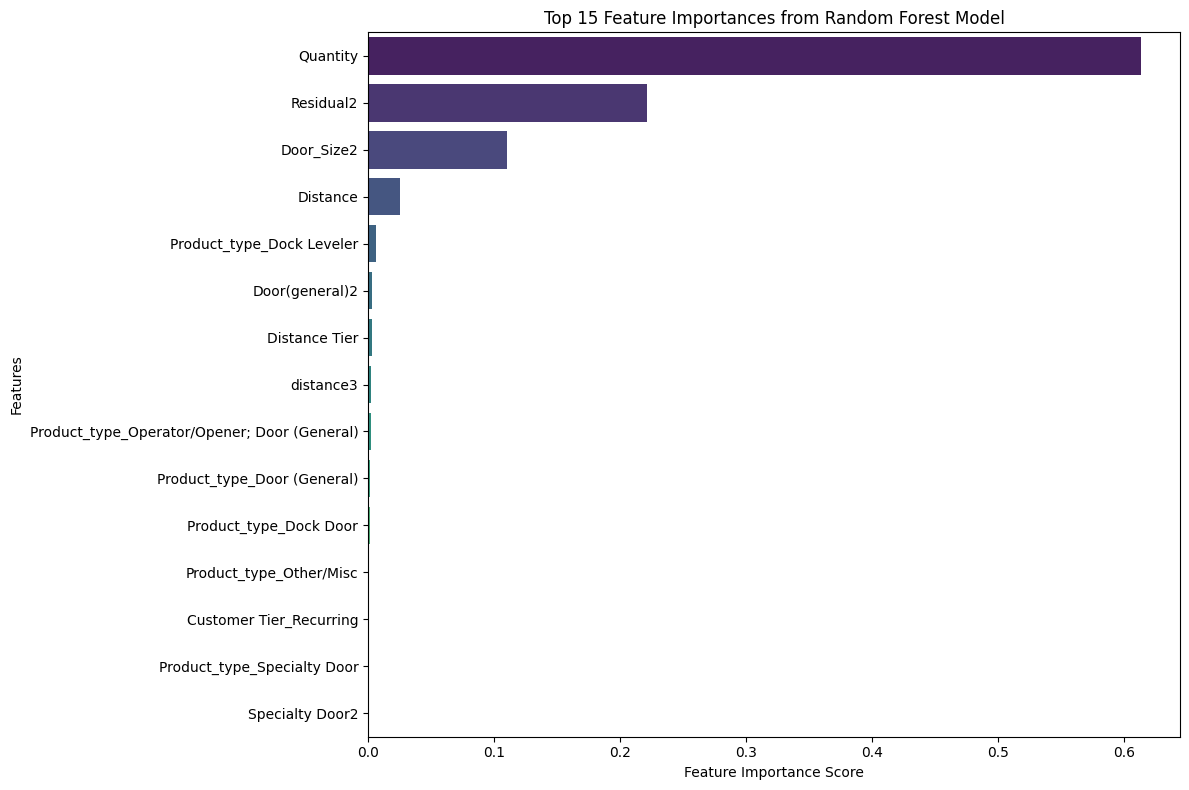

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained Random Forest model
feature_importances = rf_model.feature_importances_

# Get the feature names from X_train
feature_names = X_train.columns

# Create a pandas Series for better handling
importance_df = pd.Series(feature_importances, index=feature_names)

# Sort features by importance in descending order
importance_df = importance_df.sort_values(ascending=False)

# Display the top 15 most important features
print("Top 15 Feature Importances:")
print(importance_df.head(15))

# Plot the top 15 most important features
plt.figure(figsize=(12, 8))
sns.barplot(x=importance_df.head(15).values, y=importance_df.head(15).index, palette='viridis')
plt.title('Top 15 Feature Importances from Random Forest Model')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [None, 10, 20, 30]  # Maximum depth of the tree
}

# Initialize GridSearchCV
# The estimator is rf_model (our RandomForestRegressor)
# scoring='r2' means we want to optimize for the R2 score
# cv=3 means 3-fold cross-validation
# n_jobs=-1 means use all available CPU cores
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid,
                           scoring='r2', cv=3, n_jobs=-1, verbose=2)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score found
print(f"\nBest parameters found: {grid_search.best_params_}")
print(f"Best R2 score from grid search: {grid_search.best_score_:.2f}")

# Assign the best estimator to our model variable for future use
rf_model_tuned = grid_search.best_estimator_

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best parameters found: {'max_depth': None, 'n_estimators': 200}
Best R2 score from grid search: 0.77


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5]
}

search = RandomizedSearchCV(
    RandomForestRegressor(),
    param_grid,
    n_iter=50,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
search.fit(X_train, y_train)
print(search.best_params_)

{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': None}


After the Grid Search completes, `rf_model_tuned` will hold the Random Forest Regressor with the optimized hyperparameters. We can then use this tuned model to make new predictions and evaluate its performance.

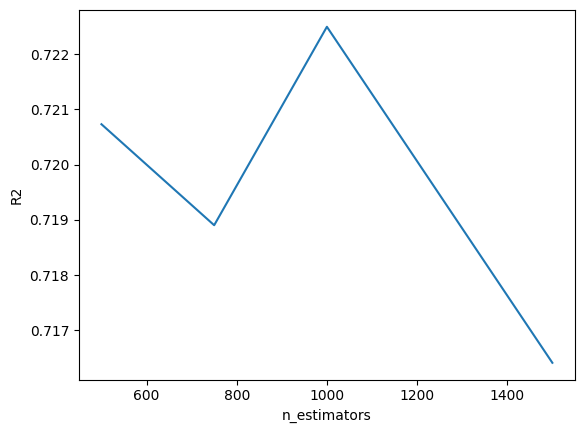

In [ ]:
# Test if more trees still help
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

scores = []
tree_counts = [500, 750, 1000, 1500]

for n in tree_counts:
    model = RandomForestRegressor(
        n_estimators=n,
        min_samples_split=2,
        min_samples_leaf=2,
        max_features=0.5,
        max_depth=10,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    scores.append(model.score(X_test, y_test))

plt.plot(tree_counts, scores)
plt.xlabel('n_estimators')
plt.ylabel('R2')
plt.show()

In [ ]:
# Install XGBoost (if not already installed)
%pip install xgboost

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize the XGBoost Regressor model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', # Objective for regression tasks
                             n_estimators=100,            # Number of boosting rounds
                             learning_rate=0.1,           # Step size shrinkage to prevent overfitting
                             random_state=42)

# Train the model on the training data
xgb_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model's performance
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = mse_xgb**0.5 # Calculate Root Mean Squared Error
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Model Performance:")
print(f"Mean Absolute Error (MAE): {mae_xgb:.2f}")
print(f"Mean Squared Error (MSE): {mse_xgb:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.2f}")
print(f"R-squared (R2): {r2_xgb:.2f}")

XGBoost Model Performance:
Mean Absolute Error (MAE): 542.19
Mean Squared Error (MSE): 3949557.26
Root Mean Squared Error (RMSE): 1987.35
R-squared (R2): 0.88


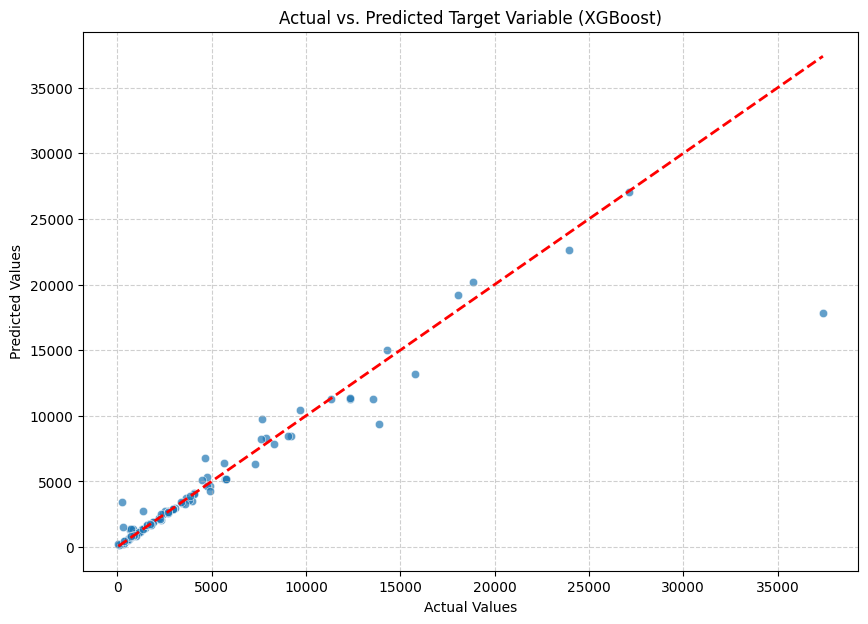

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of actual vs. predicted values
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred_xgb, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Add a diagonal line for perfect prediction
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Target Variable (XGBoost)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
import pandas as pd

# Create a dictionary to hold the metrics
metrics_data = {
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2'],
    'Random Forest': [mae, mse, rmse, r2],
    'XGBoost': [mae_xgb, mse_xgb, rmse_xgb, r2_xgb]
}

# Create a DataFrame from the dictionary
metrics_df = pd.DataFrame(metrics_data)

# Display the DataFrame, formatted to two decimal places
print("Model Performance Comparison:")
display(metrics_df.round(2))

Model Performance Comparison:


,Metric,Random Forest,XGBoost
0,MAE,698.44,542.19
1,MSE,7279685.20,3949557.26
2,RMSE,2698.09,1987.35
3,R2,0.78,0.88


Top 15 Feature Importances from XGBoost Model:
Quantity                                        0.413124
Residual2                                       0.155956
Door_Size2                                      0.125124
Customer Tier_New                               0.100367
Product_type_Operator/Opener; Door (General)    0.052010
Product_type_Dock Leveler                       0.037615
Product_type_Traffic/Crash Door                 0.037223
Firedoor2                                       0.031980
Distance                                        0.016798
Remove2                                         0.008418
Door(general)2                                  0.004609
Is_customer_Lenworth2                           0.004033
Dock Seal2                                      0.003892
Install2                                        0.003322
Operator/Opener2                                0.001781
dtype: float32


/tmp/ipykernel_7148/2731185636.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance_df_xgb.head(15).values, y=importance_df_xgb.head(15).index, palette='crest')


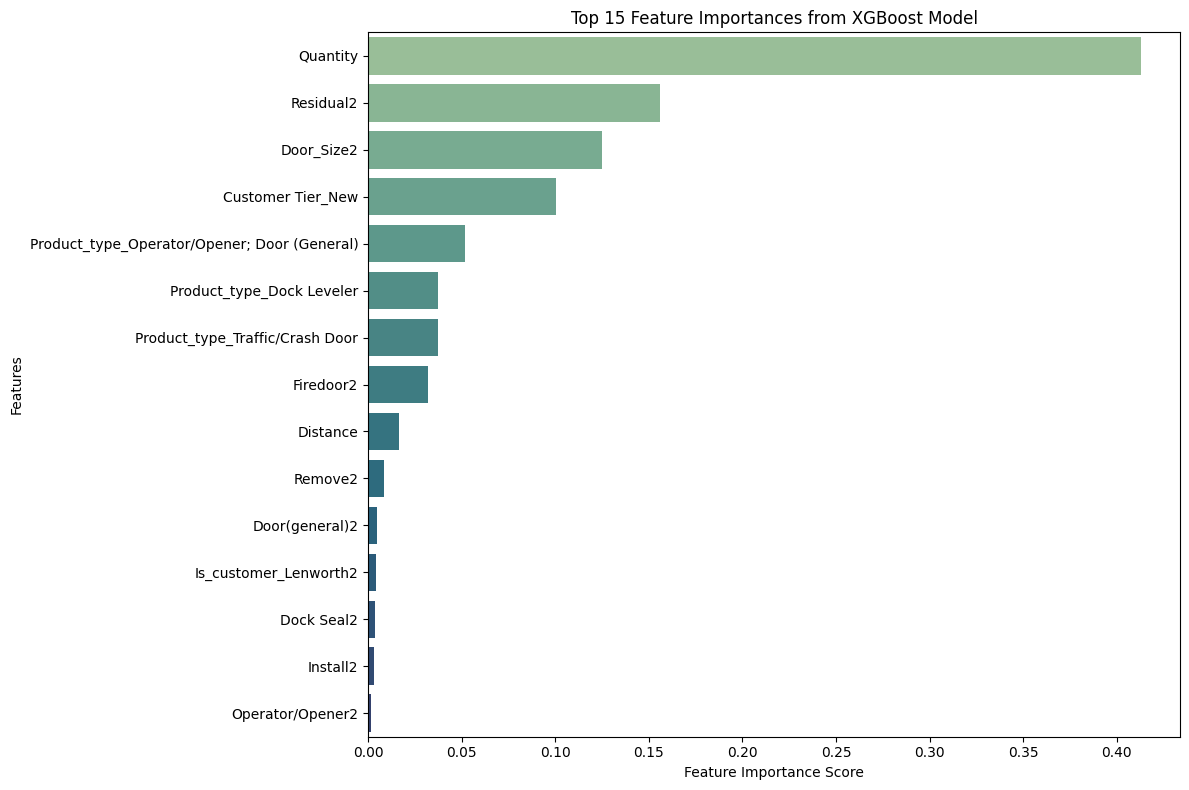

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained XGBoost model
# 'weight' is the default importance type (number of times a feature is used in a tree)
# Other options include 'gain' (average gain of splits where feature is used),
# 'cover' (average coverage of splits where feature is used), etc.
feature_importances_xgb = xgb_model.feature_importances_

# Get the feature names from X_train
feature_names_xgb = X_train.columns

# Create a pandas Series for better handling
importance_df_xgb = pd.Series(feature_importances_xgb, index=feature_names_xgb)

# Sort features by importance in descending order
importance_df_xgb = importance_df_xgb.sort_values(ascending=False)

# Display the top 15 most important features
print("Top 15 Feature Importances from XGBoost Model:")
print(importance_df_xgb.head(15))

# Plot the top 15 most important features
plt.figure(figsize=(12, 8))
sns.barplot(x=importance_df_xgb.head(15).values, y=importance_df_xgb.head(15).index, palette='crest')
plt.title('Top 15 Feature Importances from XGBoost Model')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [ ]:
# Save the DataFrame to a CSV file
df.to_csv('encoded_data.csv', index=False)

print("DataFrame saved to encoded_data.csv. You can download it from the file browser on the left.")

DataFrame saved to encoded_data.csv. You can download it from the file browser on the left.


In [ ]:
import pickle

# Save your trained model
# Assuming xgb_model is the desired model to save based on previous steps.
# If you prefer a different model (e.g., rf_model_tuned), replace xgb_model accordingly.
with open('pricing_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Load and predict
def calculate_price(job_params):
    # This function `engineer_features` needs to be defined by you
    # to transform raw job_params into the features the model expects.
    # For demonstration, we'll assume job_params are already in the correct feature format for now.
    # features = engineer_features(job_params) # your existing pipeline
    # For now, let's assume job_params directly provide the features if engineer_features is not defined.
    # You will need to implement engineer_features based on how you prepared X_train.
    features = job_params # Placeholder: Replace with actual feature engineering logic
    price = xgb_model.predict([features])[0]
    return round(price, 2)

In [ ]:
import json
with open('feature_columns.json', 'w') as f:
    json.dump(X_train.columns.tolist(), f, indent=2)